# Does the NASA PAM pool contain the species BirdSet asks for?

The BirdSet probing result for every NASA arm is a null: at 400k cold-start,
layerwise test-mean cmAP is 0.4389 (XC only) against 0.4357 (events 25 %), 0.4290
(regions 25 %) and 0.4383 (regions 50 %) — a `-0.001 … -0.010` band, narrower
than the **0.014 cmAP that two XC-only runs differ by on initialisation alone**.
No dose-response, no windowing effect.

This notebook tests one explanation that costs no GPU. The curated PAM is not
background: `curate_nasa.py` keeps 5 s windows whose top AudioProtoPNet species
probability clears 0.7, so the pool is **field-recorded bird vocalisations** with
a predicted species attached. That makes a precondition checkable which the
domain-shift thesis leaves implicit:

> **H:** PAM improves focal→soundscape transfer in proportion to how much of the
> target label space the PAM pool actually contains. Field-domain channel
> statistics on their own do not transfer — the field recordings have to carry
> the target taxa.

Two overlap measures, and the distinction is the point:

* **`pam_mass_on_target`** — the share of PAM *draws during pretraining* whose
  predicted species is in the task's label set. This is exposure: what the model
  actually sees.
* **`labelspace_coverage`** — the share of the task's species that appear
  *anywhere* in the pool, unweighted. This is presence, not exposure.

**Read the caveats with the numbers.** n = 7 test tasks per arm, one probe seed
each, and the deltas being regressed are themselves smaller than the init effect.
This is a hypothesis-generating analysis on existing runs, not a test with power —
and as section 5 shows, the correlation it produces is not consistent across arms.
The descriptive result in sections 2–3 does not depend on that correlation. The
`top_species` labels are AudioProtoPNet predictions at confidence ≥ 0.7, not
verified identifications, so overlap is measured in the curator's label space.


In [1]:
import runpy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import wandb
from huggingface_hub import hf_hub_download
from scipy.stats import binomtest, mannwhitneyu, pearsonr, spearmanr

REPO = Path("/home/moritz_earthspecies_org/soundscape_mae")
pd.set_option("display.width", 200)

/home/moritz_earthspecies_org/soundscape_mae/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. BirdSet label spaces

BirdSet ships its per-task eBird code lists in `classes.py` in the dataset repo,
so the label spaces come from the benchmark itself rather than being retyped
here. `POW` is the conventional validation task: carried through the tables and
drawn in the plots, but excluded from every correlation.

In [2]:
# task -> the variable in BirdSet's classes.py holding its eBird codes, and the
# recording region (the region is only used for plot annotation).
BIRDSET_CLASS_VAR = {
    "HSN": "BIRD_NAMES_HIGH_SIERRAS",
    "NBP": "BIRD_NAMES_NIPS4BPLUS",
    "NES": "BIRD_NAMES_COLUMBIA_COSTA_RICA",
    "PER": "BIRD_NAMES_AMAZON_BASIN",
    "POW": "BIRD_NAMES_POWDERMILL_NATURE",
    "SNE": "BIRD_NAMES_SIERRA_NEVADA",
    "SSW": "BIRD_NAMES_SAPSUCKER",
    "UHH": "BIRD_NAMES_HAWAII",
}
TASK_REGION = {
    "HSN": "Sierra Nevada, CA", "NBP": "France (NIPS4B)", "NES": "Colombia / Costa Rica",
    "PER": "Amazon Basin, PE", "POW": "Powdermill, PA", "SNE": "Sierra Nevada, CA",
    "SSW": "Sapsucker Woods, NY", "UHH": "Hawaii",
}
VAL_TASKS = ["POW"]
TEST_TASKS = ["HSN", "NBP", "NES", "PER", "SNE", "SSW", "UHH"]
TASKS = VAL_TASKS + TEST_TASKS

_classes = runpy.run_path(
    hf_hub_download("DBD-research-group/BirdSet", "classes.py", repo_type="dataset")
)
TASK_CLASSES = {t: set(_classes[v]) for t, v in BIRDSET_CLASS_VAR.items()}

print(pd.DataFrame([{"task": t, "region": TASK_REGION[t], "n_classes": len(TASK_CLASSES[t])}
                    for t in TASKS]).to_string(index=False))

task                region  n_classes
 POW        Powdermill, PA         48
 HSN     Sierra Nevada, CA         21
 NBP       France (NIPS4B)         51
 NES Colombia / Costa Rica         89
 PER      Amazon Basin, PE        132
 SNE     Sierra Nevada, CA         56
 SSW   Sapsucker Woods, NY         81
 UHH                Hawaii         27


## 2. What is in the curated PAM pool

`curated/nasa/{bioscape,s2l}07.parquet` are the curation outputs at threshold
0.7 — one row per kept 5 s detection, with `top_species` (an eBird code from
AudioProtoPNet's `id2label`) and `confidence`.

The two sources are sampled at fixed relative weight in every arm — `[384, 43,
85]` at 25 % PAM and `[256, 85, 171]` at 50 % — so BioScape:S2L is 1:1.98 / 1:2.01
either way and the **within-PAM composition is constant across arms** at ~34 % /
66 %. That is what `W_BIO` / `W_S2L` below encode, and it is why one overlap
number applies to all three NASA arms.

In [3]:
bioscape = pl.read_parquet(REPO / "curated/nasa/bioscape07.parquet")
s2l = pl.read_parquet(REPO / "curated/nasa/s2l07.parquet")

# within-PAM sampling composition (43:85 at 25% PAM, 85:171 at 50% -> same ratio)
W_BIO, W_S2L = 43 / 128, 85 / 128


def species_counts(df: pl.DataFrame) -> dict[str, int]:
    return dict(df.group_by("top_species").len().iter_rows())


counts_bio, counts_s2l = species_counts(bioscape), species_counts(s2l)
total_bio, total_s2l = sum(counts_bio.values()), sum(counts_s2l.values())

# per-species share of PAM draws during pretraining
pam_mass = {
    sp: W_BIO * counts_bio.get(sp, 0) / total_bio + W_S2L * counts_s2l.get(sp, 0) / total_s2l
    for sp in set(counts_bio) | set(counts_s2l)
}

for name, df, counts, total in [("BioScape (Cape Floristic, ZA)", bioscape, counts_bio, total_bio),
                                ("S2L (Sonoma County, CA)", s2l, counts_s2l, total_s2l)]:
    top = sorted(counts.items(), key=lambda kv: -kv[1])[:8]
    print(f"{name}: {total:,} detections, {len(counts)} species, "
          f"{df['confidence'].mean():.3f} mean confidence")
    print("   top:", ", ".join(f"{s} {c/total:.1%}" for s, c in top), "\n")

print(f"PAM draws are {W_BIO:.1%} BioScape / {W_S2L:.1%} S2L in every arm.")

BioScape (Cape Floristic, ZA): 46,725 detections, 407 species, 0.755 mean confidence
   top: finnig1 20.8%, capbun1 11.6%, carcha1 8.7%, faifly1 6.4%, comqua1 5.9%, reccuc1 4.2%, malsun1 3.4%, batapa2 3.0% 

S2L (Sonoma County, CA): 108,440 detections, 372 species, 0.737 mean confidence
   top: pasfly 28.2%, chbchi 10.8%, comrav 4.0%, cowscj1 3.6%, whcspa 3.6%, lazbun 3.2%, orcwar 2.7%, grhowl 2.3% 

PAM draws are 33.6% BioScape / 66.4% S2L in every arm.


## 3. Overlap per task

`pam_mass_on_target` is exposure (share of PAM draws on a species in the task's
label set); `labelspace_coverage` is presence (share of the task's species found
anywhere in the pool). `bio_share` / `s2l_share` split the mass by source, before
the 34/66 weighting.

In [4]:
rows = []
for task, classes in TASK_CLASSES.items():
    on_bio = sum(c for s, c in counts_bio.items() if s in classes) / total_bio
    on_s2l = sum(c for s, c in counts_s2l.items() if s in classes) / total_s2l
    shared = {s for s in classes if s in pam_mass}
    rows.append({
        "task": task,
        "n_classes": len(classes),
        "pam_mass_on_target": W_BIO * on_bio + W_S2L * on_s2l,
        "labelspace_coverage": len(shared) / len(classes),
        "n_shared": len(shared),
        "bio_share": on_bio,
        "s2l_share": on_s2l,
    })

overlap = pd.DataFrame(rows).set_index("task").reindex(TASKS)
print(overlap.round(4).to_string())

      n_classes  pam_mass_on_target  labelspace_coverage  n_shared  bio_share  s2l_share
task                                                                                    
POW          48              0.0651               0.4792        23     0.0002     0.0980
HSN          21              0.0654               0.4286         9     0.0000     0.0985
NBP          51              0.0107               0.7843        40     0.0179     0.0071
NES          89              0.0124               0.0899         8     0.0003     0.0185
PER         132              0.0002               0.0833        11     0.0004     0.0001
SNE          56              0.4695               0.7500        42     0.0039     0.7051
SSW          81              0.0876               0.5185        42     0.0045     0.1297
UHH          27              0.0133               0.1852         5     0.0066     0.0167


### Concentration — how many species carry the overlap

A task's mass can come from a broad slice of the pool or from one very common
species. That difference decides how the correlation below should be read, so it
is worth seeing explicitly.

In [5]:
for task in overlap.sort_values("pam_mass_on_target", ascending=False).index:
    contrib = sorted(((pam_mass[s], s) for s in TASK_CLASSES[task] if s in pam_mass), reverse=True)
    total = sum(m for m, _ in contrib)
    if total == 0:
        print(f"{task}: no overlap"); continue
    head = ", ".join(f"{s} {m:.4f}" for m, s in contrib[:5])
    top2 = sum(m for m, _ in contrib[:2]) / total
    print(f"{task}: mass {total:.4f} | top-2 = {top2:.0%} of it | {head}")

SNE: mass 0.4695 | top-2 = 55% of it | pasfly 0.1873, chbchi 0.0718, comrav 0.0264, whcspa 0.0240, lazbun 0.0215
SSW: mass 0.0876 | top-2 = 44% of it | comrav 0.0264, herthr 0.0118, brncre 0.0107, houwre 0.0068, daejun 0.0060
HSN: mass 0.0654 | top-2 = 65% of it | whcspa 0.0240, orcwar 0.0182, herthr 0.0118, daejun 0.0060, warvir 0.0054
POW: mass 0.0651 | top-2 = 59% of it | comrav 0.0264, herthr 0.0118, brncre 0.0107, wiltur 0.0074, haiwoo 0.0022
UHH: mass 0.0133 | top-2 = 82% of it | wiltur 0.0074, calqua 0.0035, comwax 0.0020, skylar 0.0003, houfin 0.0001
NES: mass 0.0124 | top-2 = 90% of it | houwre 0.0068, acowoo 0.0044, wewpew 0.0009, yetvir 0.0002, rucwar 0.0001
NBP: mass 0.0107 | top-2 = 37% of it | redcro 0.0024, barswa 0.0016, gretit1 0.0013, eurbla 0.0006, comchi1 0.0006
PER: mass 0.0002 | top-2 = 49% of it | strcuc1 0.0001, coffal1 0.0000, strxen1 0.0000, muswre2 0.0000, bartin2 0.0000


## 4. Per-task NASA deltas (layerwise probe)

Resolved from W&B the same way `birdset_results_nasa.ipynb` does it: the backbone
comes from the **full** `trainer.resume_from_checkpoint` path (basenames collide
across runs) and the head from `module.model._target_`, never from the run name.
One run per (task, arm), preferring the most recent finished one.

In [6]:
CKPT_TO_ARM = {
    "XC_400k_cold.ckpt": "XC-only",       # cold-start 400k, the control
    "XC_nasa_400k.ckpt": "events 25%",
    "XC_nasa_400k_v2.ckpt": "regions 25%",
    "XC_nasa_50_400k.ckpt": "regions 50%",
}
NASA_ARMS = ["events 25%", "regions 25%", "regions 50%"]

records = []
for run in wandb.Api().runs("mwirth/soundscape_ssl"):
    ckpt = str((run.config.get("trainer", {}) or {}).get("resume_from_checkpoint") or "")
    arm = CKPT_TO_ARM.get(ckpt.rsplit("/", 1)[-1])
    target = ((run.config.get("module", {}) or {}).get("model", {}) or {}).get("_target_", "")
    task = run.name.split("-")[0]
    if arm is None or "Layerwise" not in str(target) or task not in TASKS:
        continue
    records.append({"task": task, "arm": arm, "state": run.state,
                    "created": pd.to_datetime(run.created_at, utc=True),
                    # label-space era: the three GBIF-linkage repairs of §6 changed
                    # NES/PER/SNE from 88/131/55 classes to 89/132/56, so a task
                    # whose arms disagree here is comparing two different problems
                    "n_classes_run": (run.config.get("data", {}) or {}).get("num_classes"),
                    "cmAP": run.summary.get("test/MultilabelAveragePrecision")})

runs_df = pd.DataFrame(records)
runs_df["_finished"] = (runs_df["state"] == "finished").astype(int)
runs_df = (runs_df.sort_values(["_finished", "created"])
                  .drop_duplicates(["task", "arm"], keep="last")
                  .drop(columns="_finished"))

unfinished = runs_df.loc[runs_df["state"] != "finished", ["task", "arm", "state"]]
if len(unfinished):
    print("WARNING — kept runs that are not finished (their cmAP will move):")
    print(unfinished.to_string(index=False), "\n")

mixed = (runs_df.groupby("task")["n_classes_run"].nunique() > 1)
if mixed.any():
    print("WARNING — these tasks mix label-space eras across arms, so their row is "
          "not a like-for-like comparison (see §6/§10):")
    print(runs_df.loc[runs_df["task"].isin(mixed[mixed].index),
                      ["task", "arm", "n_classes_run", "created"]]
                 .sort_values(["task", "arm"]).to_string(index=False), "\n")

cmap = runs_df.pivot(index="task", columns="arm", values="cmAP").reindex(
    index=TASKS, columns=["XC-only"] + NASA_ARMS)
deltas = cmap[NASA_ARMS].sub(cmap["XC-only"], axis=0)

print("layerwise cmAP:"); print(cmap.round(4).to_string())
print("\ntest-mean (POW excluded):"); print(cmap.loc[TEST_TASKS].mean().round(4).to_string())
print("\ndelta vs XC-only:"); print(deltas.round(4).to_string())

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/moritz_earthspecies_org/.netrc.


layerwise cmAP:
arm   XC-only  events 25%  regions 25%  regions 50%
task                                               
POW    0.5377      0.5414       0.5176       0.5312
HSN    0.5202      0.5312       0.4949       0.5056
NBP    0.7192      0.6970       0.6953       0.7186
NES    0.4124      0.4009       0.4046       0.4046
PER    0.3078      0.3007       0.3025       0.2988
SNE    0.3507      0.3716       0.3506       0.3710
SSW    0.4541      0.4596       0.4431       0.4476
UHH    0.3079      0.2891       0.3119       0.3218

test-mean (POW excluded):
arm
XC-only        0.4389
events 25%     0.4357
regions 25%    0.4290
regions 50%    0.4383

delta vs XC-only:
arm   events 25%  regions 25%  regions 50%
task                                      
POW       0.0037      -0.0202      -0.0065
HSN       0.0110      -0.0253      -0.0147
NBP      -0.0221      -0.0239      -0.0006
NES      -0.0115      -0.0078      -0.0077
PER      -0.0071      -0.0053      -0.0090
SNE       0.0210      -0.

## 5. Do the deltas track overlap?

Spearman on the 7 test tasks per arm, plus two robustness checks that matter
here: dropping `SNE` (an outlier in both x and y — see the concentration cell)
and dropping `NBP` (the largest negative). `labelspace_coverage` and `n_classes`
are carried as controls: if H is right, mass predicts and those two do not.

In [7]:
joined = deltas.join(overlap)
stats = []
for arm in NASA_ARMS:
    sub = joined.loc[TEST_TASKS, [arm, "pam_mass_on_target", "labelspace_coverage", "n_classes"]].dropna()
    row = {"arm": arm, "n": len(sub)}
    row["rho_mass"] = spearmanr(sub["pam_mass_on_target"], sub[arm]).statistic
    row["p_mass"] = spearmanr(sub["pam_mass_on_target"], sub[arm]).pvalue
    row["rho_coverage"] = spearmanr(sub["labelspace_coverage"], sub[arm]).statistic
    row["rho_n_classes"] = spearmanr(sub["n_classes"], sub[arm]).statistic
    for drop in ["SNE", "NBP"]:
        keep = sub.drop(index=drop, errors="ignore")
        row[f"rho_mass_no_{drop}"] = spearmanr(keep["pam_mass_on_target"], keep[arm]).statistic
    stats.append(row)

stats_df = pd.DataFrame(stats).set_index("arm")
print(stats_df.round(3).to_string())

# pooled over the three arms; the p-value is optimistic because each task
# contributes three non-independent points (same tasks, same overlap value).
pool = joined.loc[TEST_TASKS, NASA_ARMS + ["pam_mass_on_target"]].melt(
    id_vars="pam_mass_on_target", var_name="arm", value_name="delta").dropna()
r = spearmanr(pool["pam_mass_on_target"], pool["delta"])
print(f"\npooled n={len(pool)}  spearman={r.statistic:+.3f} (p={r.pvalue:.3f}, optimistic)")

mean_delta = joined.loc[TEST_TASKS, NASA_ARMS].mean(axis=1)
rm = spearmanr(joined.loc[TEST_TASKS, "pam_mass_on_target"], mean_delta)
print(f"mean-over-arms delta  n=7  spearman={rm.statistic:+.3f} (p={rm.pvalue:.3f})")
print(pd.DataFrame({"pam_mass_on_target": joined.loc[TEST_TASKS, "pam_mass_on_target"].round(4),
                    "mean_delta": mean_delta.round(4)})
        .sort_values("pam_mass_on_target", ascending=False).to_string())

             n  rho_mass  p_mass  rho_coverage  rho_n_classes  rho_mass_no_SNE  rho_mass_no_NBP
arm                                                                                            
events 25%   7     0.714   0.071         0.071          0.000            0.543            0.714
regions 25%  7     0.071   0.879        -0.321          0.250           -0.314           -0.086
regions 50%  7     0.393   0.383         0.536         -0.143            0.029            0.543

pooled n=21  spearman=+0.413 (p=0.063, optimistic)
mean-over-arms delta  n=7  spearman=+0.571 (p=0.180)
      pam_mass_on_target  mean_delta
task                                
SNE               0.4695      0.0137
SSW               0.0876     -0.0040
HSN               0.0654     -0.0097
UHH               0.0133     -0.0003
NES               0.0124     -0.0090
NBP               0.0107     -0.0155
PER               0.0002     -0.0071


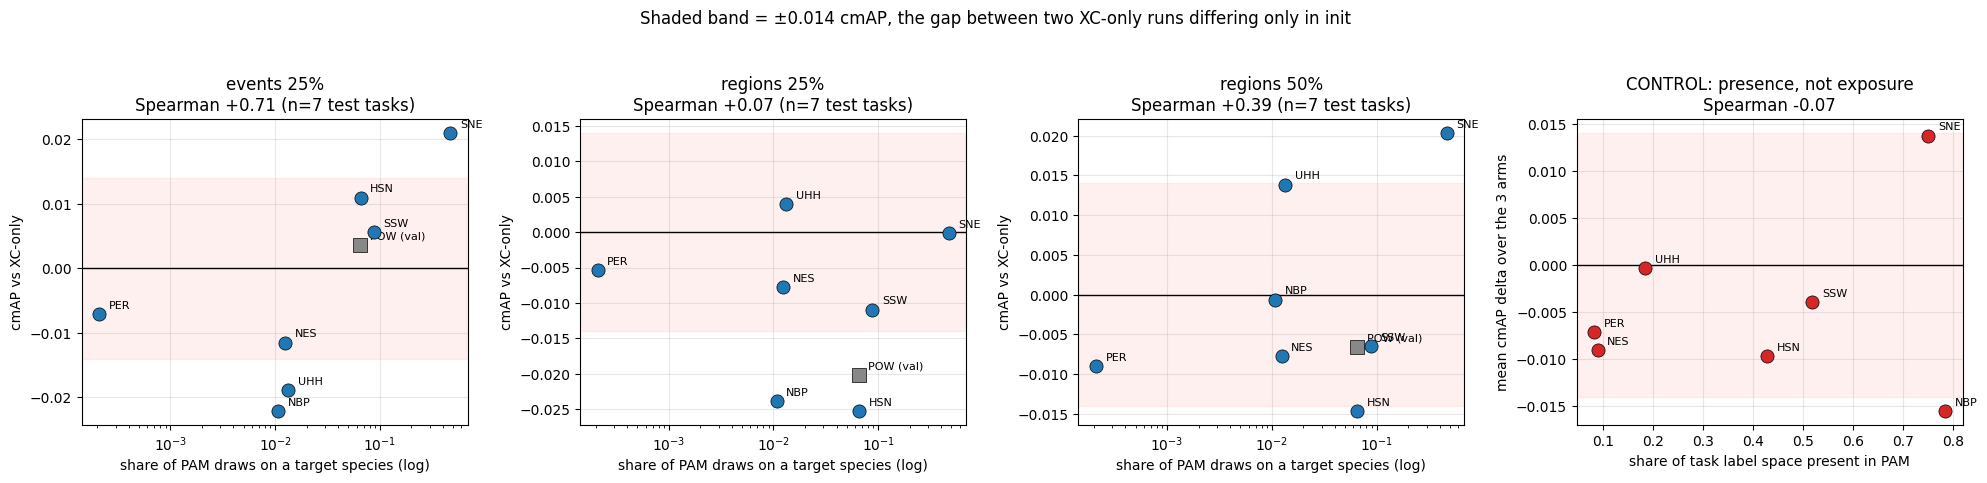

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
FLOOR = 0.014  # cmAP between two XC-only runs differing only in initialisation

for ax, arm in zip(axes[:3], NASA_ARMS):
    for task in TASKS:
        if pd.isna(joined.loc[task, arm]):
            continue
        x, y = joined.loc[task, "pam_mass_on_target"], joined.loc[task, arm]
        is_val = task in VAL_TASKS
        ax.scatter(max(x, 1e-4), y, s=90, zorder=3,
                   color="#888888" if is_val else "#1f77b4",
                   marker="s" if is_val else "o",
                   edgecolor="black", linewidth=0.5)
        ax.annotate(f"{task}{' (val)' if is_val else ''}", (max(x, 1e-4), y),
                    textcoords="offset points", xytext=(7, 4), fontsize=8)
    ax.axhline(0, color="black", linewidth=1)
    ax.axhspan(-FLOOR, FLOOR, color="red", alpha=0.06, zorder=0)
    ax.set_xscale("log")
    ax.set_xlabel("share of PAM draws on a target species (log)")
    ax.set_ylabel("cmAP vs XC-only")
    rho = stats_df.loc[arm, "rho_mass"]
    ax.set_title(f"{arm}\nSpearman {rho:+.2f} (n=7 test tasks)")
    ax.grid(alpha=0.3)

# negative control: presence in the pool, unweighted by exposure
ax = axes[3]
for task in TEST_TASKS:
    x, y = joined.loc[task, "labelspace_coverage"], mean_delta[task]
    ax.scatter(x, y, s=90, color="#d62728", edgecolor="black", linewidth=0.5, zorder=3)
    ax.annotate(task, (x, y), textcoords="offset points", xytext=(7, 4), fontsize=8)
ax.axhline(0, color="black", linewidth=1)
ax.axhspan(-FLOOR, FLOOR, color="red", alpha=0.06, zorder=0)
ax.set_xlabel("share of task label space present in PAM")
ax.set_ylabel("mean cmAP delta over the 3 arms")
ax.set_title(f"CONTROL: presence, not exposure\nSpearman "
             f"{spearmanr(joined.loc[TEST_TASKS, 'labelspace_coverage'], mean_delta).statistic:+.2f}")
ax.grid(alpha=0.3)

fig.suptitle("Shaded band = ±0.014 cmAP, the gap between two XC-only runs differing only in init", y=1.04)
fig.tight_layout()
plt.show()

## 6. The probe's label space is not BirdSet's label space

Sections 3–5 measure overlap against BirdSet's *nominal* eBird lists. The probe
does not score those. It scores the `class_ids` anchor in
`configs/data/datasets/train/birdset/{task}.yaml`, and when the §4 arms were
probed that list was one species short for three tasks:

| task | config `class_ids` (as probed in §4) | BirdSet classes |
| --- | --- | --- |
| NES | 88 | 89 |
| PER | 131 | 132 |
| SNE | 55 | 56 |

Since the config uses the same `&cls` anchor for train and test labels, a test
positive for a missing species cannot be represented: it is dropped from the label
vector, the probe has no output unit for it, and a window whose only positive was
that species becomes an all-negative window. So PAM exposure on such a species
could not raise cmAP no matter how much of it there was. That mattered here
because of *which* species it was — `pasfly` (*Empidonax difficilis*), 18.7 % of
all PAM draws, was `SNE`'s missing class.

**Repaired, and not for the reason first assumed.** The three species are not
absent from Xeno-Canto: `pasfly`, `runwre1` (*Campylorhynchus rufinucha*) and
`scbwoo5` (*Celeus grammicus*) have 251 / 10 / 71 recordings in the split the probe
trains on. What is missing is the **GBIF linkage in BirdSet's own metadata** — no
annotation row carries a `gbifID` for them — so they never entered the `&cls` list.
The three task configs now add the id to `&cls` and re-attach it on the test side
with `AppendLabelWhereConfig`, which is why the cell below prints `short_by = 0`
and the table after it finds no verified-absent mass anywhere. §10 scores those
classes; §4 and §5 still hold pre-repair runs for two of the four arms, and the
warning added to §4 flags every row that mixes the two label-space eras.

That leaves the crosswalk itself, which goes
gbifID → binomial using the **Xeno-Canto metadata the probe actually trains on** —
`XenoCanto.VERSIONS["0.2.0"]["split_paths"]["all"]` on the alp-data bucket, the
same split the BirdSet probe configs request (`dataset_name: xeno-canto-raw`,
`version: 0.2.0`, `split: all`). The CSV is 1.2 GB, so the taxonomy columns are
cached once to `metadata/xc_v0.2.0_taxonomy.parquet`; delete that file to refetch.
`canonical_name` is the GBIF-standardised binomial, so it is used directly rather
than parsing authority strings.

A species is only reported as **absent** when its binomial resolved to a gbifID and
that gbifID is in no config list; an unresolvable name is reported as `unknown` and
never counted as absent.

In [9]:
import re

XC_TAXONOMY_CACHE = REPO / "metadata/xc_v0.2.0_taxonomy.parquet"
XC_TAXONOMY_COLS = ["gbifID", "canonical_name", "speciesKey", "taxonKey"]


def load_xc_taxonomy() -> pl.DataFrame:
    """Taxonomy columns of the XC split the probe trains on (cached locally)."""
    if not XC_TAXONOMY_CACHE.exists():
        import soundscape_ssl.data.datasets._gcs_anon  # noqa: F401  (anonymous GCS)
        from alp_data.datasets.xeno_canto import XenoCanto
        from alp_data.io import filesystem_from_path

        source = XenoCanto.VERSIONS["0.2.0"]["split_paths"]["all"]
        print(f"caching taxonomy from {source} (1.2 GB, one time) ...")
        fs = filesystem_from_path(source)
        with fs.open(str(source).replace("gs://", ""), "rb") as fh:
            pl.read_csv(fh, columns=XC_TAXONOMY_COLS, infer_schema_length=10_000,
                        schema_overrides={c: pl.Utf8 for c in XC_TAXONOMY_COLS}
                        ).write_parquet(XC_TAXONOMY_CACHE)
    return (pl.read_parquet(XC_TAXONOMY_CACHE)
              .with_columns(pl.col("gbifID").cast(pl.Float64).cast(pl.Int64).alias("gbif")))


xc_meta = load_xc_taxonomy()


# probe label space per task: the `&cls` gbifID anchor the probe actually scores
def config_class_ids(task: str) -> set[int]:
    txt = (REPO / f"configs/data/datasets/train/birdset/{task.lower()}.yaml").read_text()
    body = re.search(r"values:\s*&cls\s*\[([^\]]*)\]", txt, re.S).group(1)
    return {int(x.strip()) for x in body.split(",") if x.strip()}


PROBE_CLASS_IDS = {t: config_class_ids(t) for t in TASKS}
binomial_to_gbif = {name: int(g) for name, g in
                    xc_meta.group_by("canonical_name").agg(pl.col("gbif").mode().first()).iter_rows()
                    if g is not None}
xc_recs_per_gbif = dict(xc_meta.group_by("gbif").len().iter_rows())

print(f"XC v0.2.0 'all': {xc_meta.height:,} recordings, {len(binomial_to_gbif):,} binomials")
print(pd.DataFrame([{"task": t, "probe_classes": len(PROBE_CLASS_IDS[t]),
                     "birdset_classes": len(TASK_CLASSES[t]),
                     "short_by": len(TASK_CLASSES[t]) - len(PROBE_CLASS_IDS[t]),
                     "classes_with_0_xc": sum(1 for i in PROBE_CLASS_IDS[t]
                                              if xc_recs_per_gbif.get(i, 0) == 0)}
                    for t in TASKS]).to_string(index=False))

XC v0.2.0 'all': 744,242 recordings, 11,748 binomials
task  probe_classes  birdset_classes  short_by  classes_with_0_xc
 POW             48               48         0                  0
 HSN             21               21         0                  0
 NBP             51               51         0                  0
 NES             89               89         0                  0
 PER            132              132         0                  1
 SNE             56               56         0                  0
 SSW             81               81         0                  0
 UHH             27               27         0                  2


In [10]:
# eBird code -> binomial for the species that carry the overlap mass (section 3's
# concentration cell). Only these need verifying: the top two species hold
# 37-90% of every task's overlap.
EBIRD_TO_BINOMIAL = {
    "pasfly": "Empidonax difficilis",   "chbchi": "Poecile rufescens",
    "comrav": "Corvus corax",           "whcspa": "Zonotrichia leucophrys",
    "lazbun": "Passerina amoena",       "orcwar": "Leiothlypis celata",
    "herthr": "Catharus guttatus",      "brncre": "Certhia americana",
    "houwre": "Troglodytes aedon",      "daejun": "Junco hyemalis",
    "warvir": "Vireo gilvus",           "wiltur": "Meleagris gallopavo",
    "haiwoo": "Dryobates villosus",     "reshaw": "Buteo lineatus",
    "calqua": "Callipepla californica", "comwax": "Estrilda astrild",
    "skylar": "Alauda arvensis",        "houfin": "Haemorhous mexicanus",
    "acowoo": "Melanerpes formicivorus","wewpew": "Contopus sordidulus",
    "yetvir": "Vireo flavifrons",       "rucwar": "Basileuterus rufifrons",
    "redcro": "Loxia curvirostra",      "barswa": "Hirundo rustica",
    "gretit1": "Parus major",           "eurbla": "Turdus merula",
    "comchi1": "Phylloscopus collybita","cowscj1": "Aphelocoma californica",
    "caltow": "Melozone crissalis",     "bewwre": "Thryomanes bewickii",
}

def probe_status(code: str, task: str) -> str:
    """scoreable | absent | unknown -- 'absent' only when the name resolved."""
    binom = EBIRD_TO_BINOMIAL.get(code)
    gbif = binomial_to_gbif.get(binom) if binom else None
    if gbif is None:
        return "unknown"
    return "scoreable" if gbif in PROBE_CLASS_IDS[task] else "absent"

rows = []
for task in overlap.sort_values("pam_mass_on_target", ascending=False).index:
    contrib = sorted(((pam_mass[s], s) for s in TASK_CLASSES[task] if s in pam_mass), reverse=True)
    nominal = sum(m for m, _ in contrib)
    by = {"scoreable": 0.0, "absent": 0.0, "unknown": 0.0}
    for m, s in contrib:
        by[probe_status(s, task)] += m
    rows.append({"task": task, "nominal_mass": nominal, **by,
                 "verified_absent_frac": by["absent"] / nominal if nominal else 0.0})

label_space = pd.DataFrame(rows).set_index("task")
print(label_space.round(4).to_string())

pasfly_share = pam_mass["pasfly"]
in_any = [t for t in TASKS if probe_status("pasfly", t) == "scoreable"]
print(f"\npasfly (Empidonax difficilis) = {pasfly_share:.1%} of ALL PAM draws; "
      f"scoreable by: {in_any or 'no task'}")
print(f"SNE on-target exposure: nominal {label_space.loc['SNE','nominal_mass']:.4f} -> "
      f"{label_space.loc['SNE','scoreable'] + label_space.loc['SNE','unknown']:.4f} "
      f"after removing species verified absent from its probe label space")

      nominal_mass  scoreable  absent  unknown  verified_absent_frac
task                                                                
SNE         0.4695     0.4104     0.0   0.0592                   0.0
SSW         0.0876     0.0698     0.0   0.0179                   0.0
HSN         0.0654     0.0654     0.0   0.0000                   0.0
POW         0.0651     0.0581     0.0   0.0070                   0.0
UHH         0.0133     0.0133     0.0   0.0000                   0.0
NES         0.0124     0.0123     0.0   0.0000                   0.0
NBP         0.0107     0.0068     0.0   0.0039                   0.0
PER         0.0002     0.0000     0.0   0.0002                   0.0

pasfly (Empidonax difficilis) = 18.7% of ALL PAM draws; scoreable by: ['SNE']
SNE on-target exposure: nominal 0.4695 -> 0.4695 after removing species verified absent from its probe label space


## 7. Could a taxon-matched pool be built from what is already scanned?

Section 6 says the current pool is mostly off-target. The design question that
follows is whether fixing that needs a new multi-TB scan, or whether enough
on-target audio is already on disk.

Three tiers exist locally:

* `curated/nasa/{S2L,BIOSCAPE}/shard_*.parquet` — the **full scan** at the 0.4
  curation threshold: every window the detector fired on.
* `curated/nasa/{s2l,bioscape}07.parquet` — the 0.7 pool the arms were trained on.
* `curated/nasa_audio/*_REGIONS/shard_*.parquet` — the **materialized** region
  store, with `num_samples` per region, i.e. audio already downloaded and written.

"On-target" below means the detection's `top_species` is in the union of the eight
BirdSet label sets — the most generous definition, since a pool serving all tasks
is the cheapest thing to build.

In [11]:
ALL_BIRDSET_SPECIES = set().union(*TASK_CLASSES.values())
print(f"union of the 8 BirdSet label spaces: {len(ALL_BIRDSET_SPECIES)} species")

tiers = []
for src, name in [("S2L", "S2L"), ("BIOSCAPE", "BioScape")]:
    full = pl.concat([
        pl.read_parquet(f, columns=["top_species", "confidence", "granule_ur"])
        for f in sorted((REPO / f"curated/nasa/{src}").glob("shard_*.parquet"))
    ])
    on_target = full.filter(pl.col("top_species").is_in(list(ALL_BIRDSET_SPECIES)))
    for thr in (0.4, 0.7):
        sub_all = full.filter(pl.col("confidence") >= thr)
        sub_on = on_target.filter(pl.col("confidence") >= thr)
        tiers.append({"source": name, "threshold": thr,
                      "detections": sub_all.height, "on_target": sub_on.height,
                      "on_target_pct": sub_on.height / max(sub_all.height, 1),
                      "on_target_hours": sub_on.height * 5 / 3600,
                      "on_target_granules": sub_on["granule_ur"].n_unique()})

print("\nfull detection scan, restricted to BirdSet species (5 s per detection):")
print(pd.DataFrame(tiers).round(4).to_string(index=False))

union of the 8 BirdSet label spaces: 411 species



full detection scan, restricted to BirdSet species (5 s per detection):
  source  threshold  detections  on_target  on_target_pct  on_target_hours  on_target_granules
     S2L        0.4     1844256    1170800         0.6348        1626.1111              233614
     S2L        0.7      108440      81523         0.7518         113.2264               34320
BioScape        0.4     2503829     290890         0.1162         404.0139              176512
BioScape        0.7       46725       1192         0.0255           1.6556                1023


In [12]:
# the materialized region store: audio already on disk, so an on-target subset
# needs no new download
region_rows = []
for src, name in [("S2L_REGIONS", "S2L"), ("BIOSCAPE_REGIONS", "BioScape")]:
    shards = sorted((REPO / f"curated/nasa_audio/{src}").glob("shard_*.parquet"))
    reg = pl.concat([pl.read_parquet(f, columns=["top_species", "confidence",
                                                 "num_samples", "sample_rate", "granule_ur"])
                     for f in shards])
    hours = (reg["num_samples"] / reg["sample_rate"]).sum() / 3600
    on = reg.filter(pl.col("top_species").is_in(list(ALL_BIRDSET_SPECIES)))
    on_hours = (on["num_samples"] / on["sample_rate"]).sum() / 3600
    region_rows.append({"source": name, "shards": len(shards), "regions": reg.height,
                        "hours": hours, "on_target_regions": on.height,
                        "on_target_hours": on_hours,
                        "on_target_pct": on.height / max(reg.height, 1),
                        "on_target_granules": on["granule_ur"].n_unique()})

regions_df = pd.DataFrame(region_rows)
print("materialized REGIONS store (audio already downloaded):")
print(regions_df.round(3).to_string(index=False))
tot_h, on_h = regions_df["hours"].sum(), regions_df["on_target_hours"].sum()
print(f"\ntotal {tot_h:.0f} h materialized, {on_h:.0f} h on-target ({on_h/tot_h:.1%})")
print("within-PAM composition of a taxon-matched pool built from this store: " +
      ", ".join(f"{r['source']} {r['on_target_hours']/on_h:.1%}" for _, r in regions_df.iterrows()))

materialized REGIONS store (audio already downloaded):
  source  shards  regions   hours  on_target_regions  on_target_hours  on_target_pct  on_target_granules
     S2L      40    85521 631.595              59911          464.384          0.701               35929
BioScape      40    43517 309.571               2872           15.173          0.066                2428

total 941 h materialized, 480 h on-target (51.0%)
within-PAM composition of a taxon-matched pool built from this store: S2L 96.8%, BioScape 3.2%


## 8. Is the pool what we call it?

The arms are described as pretraining on field-recorded bird vocalisations. That
rests on the detector, so three properties are worth measuring before the
description is repeated in a paper:

* **Purity** — mean confidence is 0.755 / 0.737 against a 0.7 threshold, so the
  pool may be dominated by windows that barely cleared it.
* **Pseudo-replication** — 216 h across 69,369 granules is only diverse if the
  detections are spread across granules, sites and dates.
* **Detector bias** — one species being 28 % of S2L is either real abundance or a
  failure mode, and its confidence profile discriminates the two.

In [13]:
pool = {"BioScape": bioscape, "S2L": s2l}

rows = []
for name, df in pool.items():
    conf = df["confidence"]
    per_granule = df.group_by("granule_ur").len()["len"].sort(descending=True)
    per_site = df.group_by("site").len()["len"].sort(descending=True)
    n = per_granule.len()
    rows.append({
        "source": name,
        "detections": df.height,
        "mean_conf": conf.mean(),
        "frac_conf_0.7_0.8": ((conf >= 0.7) & (conf < 0.8)).mean(),
        "frac_conf_gt_0.9": (conf >= 0.9).mean(),
        "granules": n,
        "det_per_granule_median": per_granule.median(),
        "det_per_granule_max": per_granule.max(),
        "top1pct_granule_share": per_granule.head(max(1, n // 100)).sum() / df.height,
        "sites": per_site.len(),
        "top_site_share": per_site.max() / df.height,
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))

  source  detections  mean_conf  frac_conf_0.7_0.8  frac_conf_gt_0.9  granules  det_per_granule_median  det_per_granule_max  top1pct_granule_share  sites  top_site_share
BioScape       46725     0.7549             0.8073            0.0045     23311                     1.0                   12                 0.0568    162          0.0340
     S2L      108440     0.7375             0.9559            0.0000     46058                     1.0                   12                 0.0482    121          0.0352


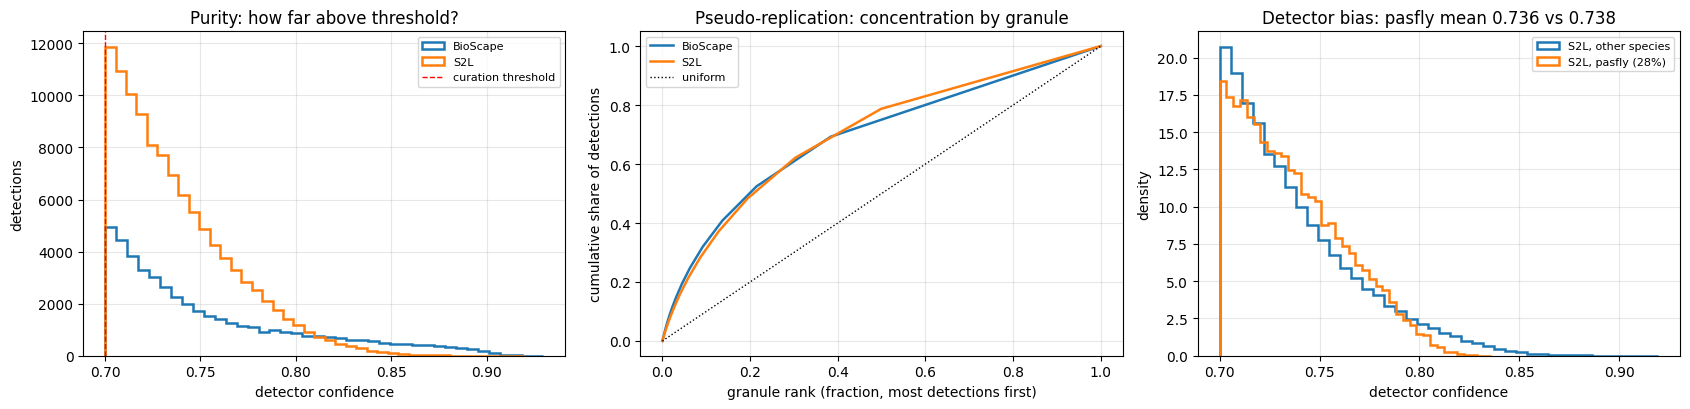

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

for name, df in pool.items():
    axes[0].hist(df["confidence"].to_numpy(), bins=40, histtype="step", linewidth=1.8, label=name)
axes[0].axvline(0.7, color="red", linestyle="--", linewidth=1, label="curation threshold")
axes[0].set_xlabel("detector confidence"); axes[0].set_ylabel("detections")
axes[0].set_title("Purity: how far above threshold?"); axes[0].legend(fontsize=8)

for name, df in pool.items():
    per_granule = df.group_by("granule_ur").len()["len"].sort(descending=True).to_numpy()
    axes[1].plot(np.arange(1, len(per_granule) + 1) / len(per_granule),
                 np.cumsum(per_granule) / per_granule.sum(), linewidth=1.8, label=name)
axes[1].plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1, label="uniform")
axes[1].set_xlabel("granule rank (fraction, most detections first)")
axes[1].set_ylabel("cumulative share of detections")
axes[1].set_title("Pseudo-replication: concentration by granule"); axes[1].legend(fontsize=8)

# detector bias: the dominant species vs the rest of its own source
dom = s2l.filter(pl.col("top_species") == "pasfly")["confidence"].to_numpy()
rest = s2l.filter(pl.col("top_species") != "pasfly")["confidence"].to_numpy()
axes[2].hist(rest, bins=40, histtype="step", density=True, linewidth=1.8, label="S2L, other species")
axes[2].hist(dom, bins=40, histtype="step", density=True, linewidth=1.8, label="S2L, pasfly (28%)")
axes[2].set_xlabel("detector confidence"); axes[2].set_ylabel("density")
axes[2].set_title(f"Detector bias: pasfly mean {dom.mean():.3f} vs {rest.mean():.3f}")
axes[2].legend(fontsize=8)

for ax in axes: ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 9. Rival explanations for the section-5 correlation

With n = 7, anything correlated with `pam_mass_on_target` across tasks is a
candidate explanation. Three observable rivals:

* **XC training volume** — how many Xeno-Canto recordings the probe had for that
  task's species. Californian species are well recorded, so overlap and XC volume
  could be collinear.
* **Label-space size** (`n_classes`).
* **Task difficulty** — the XC-only baseline cmAP itself.

The XC counts come from the split the probe actually trains on (§6), summed over
each task's `&cls` gbifIDs, so this is the training pool rather than a proxy for
it.

In [15]:
xc_pool = {t: sum(xc_recs_per_gbif.get(i, 0) for i in PROBE_CLASS_IDS[t]) for t in TASKS}

rivals = joined.copy()
rivals["xc_recordings"] = pd.Series(xc_pool)
rivals["xc_per_class"] = rivals["xc_recordings"] / rivals["n_classes"]
rivals["baseline_cmAP"] = cmap["XC-only"]

cols = ["pam_mass_on_target", "xc_recordings", "xc_per_class", "n_classes", "baseline_cmAP"]
print(rivals.loc[TASKS, cols].round(3).to_string())

print("\nSpearman of each predictor against the per-arm delta (7 test tasks):")
out = []
for arm in NASA_ARMS:
    sub = rivals.loc[TEST_TASKS, cols + [arm]].dropna()
    out.append({"arm": arm, **{c: spearmanr(sub[c], sub[arm]).statistic for c in cols}})
print(pd.DataFrame(out).set_index("arm").round(3).to_string())

print("\ncollinearity among the predictors (Spearman, 7 test tasks):")
print(rivals.loc[TEST_TASKS, cols].corr(method="spearman").round(3).to_string())

      pam_mass_on_target  xc_recordings  xc_per_class  n_classes  baseline_cmAP
task                                                                           
POW                0.065          19641       409.188         48          0.538
HSN                0.065           7193       342.524         21          0.520
NBP                0.011         108217      2121.902         51          0.719
NES                0.012          20215       227.135         89          0.412
PER                0.000          20663       156.538        132          0.308
SNE                0.470          23891       426.625         56          0.351
SSW                0.088          37559       463.691         81          0.454
UHH                0.013           4998       185.111         27          0.308

Spearman of each predictor against the per-arm delta (7 test tasks):
             pam_mass_on_target  xc_recordings  xc_per_class  n_classes  baseline_cmAP
arm                                        

In [16]:
# rank-partial correlation: mass vs delta, holding one rival constant
def partial_spearman(x, y, z):
    rx, ry, rz = (pd.Series(v).rank().to_numpy() for v in (x, y, z))
    def resid(a, b):
        b1 = np.c_[np.ones_like(b), b]
        return a - b1 @ np.linalg.lstsq(b1, a, rcond=None)[0]
    return pearsonr(resid(rx, rz), resid(ry, rz)).statistic

rows = []
for arm in NASA_ARMS:
    sub = rivals.loc[TEST_TASKS, cols + [arm]].dropna()
    row = {"arm": arm, "rho_mass": spearmanr(sub["pam_mass_on_target"], sub[arm]).statistic}
    for ctrl in ["xc_recordings", "xc_per_class", "n_classes", "baseline_cmAP"]:
        row[f"| {ctrl}"] = partial_spearman(sub["pam_mass_on_target"], sub[arm], sub[ctrl])
    rows.append(row)
print("mass-vs-delta, raw and after partialling out each rival:")
print(pd.DataFrame(rows).set_index("arm").round(3).to_string())

mass-vs-delta, raw and after partialling out each rival:
             rho_mass  | xc_recordings  | xc_per_class  | n_classes  | baseline_cmAP
arm                                                                                 
events 25%      0.714            0.715           0.762        0.765            0.741
regions 25%     0.071            0.075           0.363        0.178            0.380
regions 50%     0.393            0.406           0.306        0.370            0.422


## 10. Per-class AP: do the exposed species actually move?

§5 regressed 7 task-level deltas against a task-level overlap number. The
per-class metric added in `configs/module/metrics/map_per_class.yaml`
(`average: null`, logged by `birdset_eval.py` as `test_AP_per_class/{gbifID}`)
replaces that with **one point per (task, class)** — 505 of them — so task
identity can be absorbed and `pam_mass` is resolved to the individual species
instead of summed over a whole label space. This is the test §9's closing
paragraph asked for, and it needed no new pretraining.

Two contrasts carry the metric, and neither is the 400k events arm §4–§5 is
built on:

* **`finetune 1M`** — `XC_1M` vs `XC_nasa_1M`, layerwise **finetuning**
  (`freeze_backbone: false`), all 8 tasks. `XC_nasa_1M` is the **events 25 %**
  mix (`data.weights=[384,43,85]` over `nasa_{s2l,bioscape}_events`) at the 1M
  schedule, so §3's exposure numbers apply to it unchanged. Both sides share the
  schedule, so this is a clean NASA contrast rather than the 1M-vs-400k one.
  It is the complete pair and the section's headline.
* **`probe 400k`** — `XC_400k_cold` vs `XC_nasa_400k_v2`, frozen layerwise
  **probe**, `SNE`/`NES`/`PER` only. That is the **regions 25 %** arm — a
  different pool *and* a different head — so it is a replication check on three
  tasks, not a second estimate of the same quantity.

Three caveats to carry through the numbers. **(a) The label-space defect §6 found
is fixed**: the task configs now inject the three missing gbifIDs with
`AppendLabelWhereConfig`, so `pasfly` — 18.7 % of all PAM draws — is scoreable in
`SNE` in every run below, and §6's "it should show no effect" prediction no
longer applies. It is now the single most-exposed testable class. **(b) AP per
class is noisy in inverse proportion to its positives**, hence the `POS_MIN`
floor; without it the table contains classes swinging ±0.3 AP on 3 positive
windows. **(c) There is no per-class noise floor**: one probe seed per cell, and
the *task-level* init effect is already ±0.014 cmAP, so a per-class ΔAP under
~0.02 is not resolved by this data.

### eBird code → gbifID, and how many positives each class has

The pool speaks eBird codes (`top_species` from AudioProtoPNet's `id2label`); the
per-class metric is keyed by gbifID. `BirdSet`'s annotation splits carry both on
the same row (`ebird_code`, `gbifID`, `canonical_name`), so the crosswalk comes
from the benchmark itself — 411 codes, zero ambiguous — rather than from the
30 hand-typed binomials §6 needed. `n_pos` counts the `test_5s` windows in which
a class is positive, which is what makes its AP trustworthy or not.

In [17]:
# A class needs enough positive test windows for its AP to mean anything; 10 is
# the floor used throughout this section (the median class has 27-297 depending
# on the task, but the tails go down to 1).
POS_MIN = 10

# BirdSet's own annotation tables carry `ebird_code` and `gbifID` on the same
# row, so the crosswalk is read off the benchmark rather than typed out. Cached
# because the eight `{TASK}-test` / `{TASK}-test_5s` metadata CSVs are ~450k rows
# on GCS; delete the parquet to rebuild.
CROSSWALK_CACHE = REPO / "metadata/birdset_ebird_gbif.parquet"

# The three species whose upstream GBIF linkage failed (§6): no annotation row
# carries a gbifID for them, so they cannot come out of the crosswalk. These are
# the ids the task configs now inject with `AppendLabelWhereConfig`.
GBIF_REPAIRS = {"pasfly": (9568685, "Empidonax difficilis"),
                "runwre1": (5231482, "Campylorhynchus rufinucha"),
                "scbwoo5": (5228935, "Celeus grammicus")}


def build_crosswalk() -> pl.DataFrame:
    """eBird<->gbifID pairs from the annotation splits, positives from test_5s."""
    import ast

    import soundscape_ssl.data.datasets._gcs_anon  # noqa: F401  (anonymous GCS)
    from alp_data.datasets.birdset import BirdSet

    def as_list(x):
        if not isinstance(x, str):
            return []
        try:
            v = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return []
        return v if isinstance(v, list) else []

    rows = []
    for task in TASKS:
        ann = BirdSet(split=f"{task}-test", backend="pandas")._data.unwrap
        linked = ann[ann["ebird_code"].notna() & ann["gbifID"].notna()]
        for code, gbif, name in zip(linked["ebird_code"], linked["gbifID"], linked["canonical_name"]):
            rows.append({"task": task, "kind": "pair", "key": str(code),
                         "aux": f"{int(gbif)}|{name}", "n": 1})
        # positives per class in the split the probe is scored on
        clips = BirdSet(split=f"{task}-test_5s", backend="pandas")._data.unwrap
        pos = pd.Series([c for e in clips["ebird_code_multilabel"] for c in set(as_list(e))]).value_counts()
        rows += [{"task": task, "kind": "pos", "key": c, "aux": "", "n": int(n)} for c, n in pos.items()]
        rows.append({"task": task, "kind": "n_clips", "key": "", "aux": "", "n": len(clips)})
    return pl.DataFrame(rows)


if not CROSSWALK_CACHE.exists():
    print("building the eBird<->gbifID crosswalk from BirdSet annotation metadata ...")
    build_crosswalk().write_parquet(CROSSWALK_CACHE)
crosswalk = pl.read_parquet(CROSSWALK_CACHE)

_pairs = (crosswalk.filter(pl.col("kind") == "pair")
                   .with_columns(pl.col("aux").str.split("|").list.first().alias("gbif"),
                                 pl.col("aux").str.split("|").list.last().alias("name"))
                   .group_by("key", "gbif", "name").agg(pl.col("n").sum())
                   .sort("n", descending=True))
EBIRD_TO_GBIF, EBIRD_NAME = {}, {}
for code, gbif, name, _ in _pairs.iter_rows():             # most frequent pairing wins
    EBIRD_TO_GBIF.setdefault(code, int(gbif))
    EBIRD_NAME.setdefault(code, name)
for code, (gbif, name) in GBIF_REPAIRS.items():
    EBIRD_TO_GBIF[code], EBIRD_NAME[code] = gbif, name
GBIF_TO_EBIRD = {g: c for c, g in EBIRD_TO_GBIF.items()}

N_POS = {(t, c): n for t, c, n in
         crosswalk.filter(pl.col("kind") == "pos").select("task", "key", "n").iter_rows()}
N_CLIPS = dict(crosswalk.filter(pl.col("kind") == "n_clips").select("task", "n").iter_rows())

_n_ambiguous = _pairs.group_by("key").agg(pl.col("gbif").n_unique()).filter(pl.col("gbif") > 1).height
print(f"crosswalk: {len(EBIRD_TO_GBIF)} eBird codes -> gbifID, {_n_ambiguous} ambiguous")
print(pd.DataFrame([{"task": t, "classes": len(TASK_CLASSES[t]),
                     "unmapped": sum(1 for c in TASK_CLASSES[t] if c not in EBIRD_TO_GBIF),
                     "test_5s_clips": N_CLIPS[t],
                     "median_positives": int(np.median([N_POS.get((t, c), 0) for c in TASK_CLASSES[t]])),
                     f"classes_ge_{POS_MIN}_pos": sum(1 for c in TASK_CLASSES[t]
                                                      if N_POS.get((t, c), 0) >= POS_MIN)}
                    for t in TASKS]).to_string(index=False))

crosswalk: 411 eBird codes -> gbifID, 0 ambiguous
task  classes  unmapped  test_5s_clips  median_positives  classes_ge_10_pos
 POW       48         0           4560                51                 33
 HSN       21         0          12000                27                 14
 NBP       51         0            539                18                 37
 NES       89         0          24480                39                 65
 PER      132         0          15120                70                108
 SNE       56         0          23756                49                 40
 SSW       81         0         205200               145                 65
 UHH       27         0          36637               297                 23


### Pulling the per-class series

Resolved the same way §4 does it — backbone from the **full** checkpoint path,
head from `module.freeze_backbone`, never from the run name — with one extra
filter: a run only counts if it actually logged `test_AP_per_class/*`. `pam_mass`
comes from §2 unchanged, so every class carries the exposure the pool gives *that
species*, not its task's total.

In [18]:
# Per-class AP is logged by `configs/module/metrics/map_per_class.yaml`
# (`average: null`) under `test_AP_per_class/{gbifID}` — the key is the class id
# from the *test* label map, so it joins straight onto the crosswalk. Only the
# runs carrying that metric are usable, which is why the arms here are not the
# four of §4: the finetune pair is the complete one.
AP_CONTRASTS = {
    # contrast -> (baseline ckpt, arm ckpt, head)
    "finetune 1M": ("XC_1M.ckpt", "XC_nasa_1M.ckpt", False),           # freeze_backbone
    "probe 400k": ("XC_400k_cold.ckpt", "XC_nasa_400k_v2.ckpt", True),
}
CONTRAST_ARM = {"finetune 1M": "events 25%", "probe 400k": "regions 25%"}


def fetch_per_class_ap() -> pd.DataFrame:
    """One row per (contrast, task, class): baseline AP, arm AP, exposure, support."""
    wanted = {ck: (name, role) for name, (base, arm, _) in AP_CONTRASTS.items()
              for ck, role in [(base, "base"), (arm, "arm")]}
    heads = {name: frozen for name, (_, _, frozen) in AP_CONTRASTS.items()}

    best = {}
    for run in wandb.Api().runs("mwirth/soundscape_ssl"):
        ckpt = str((run.config.get("trainer", {}) or {}).get("resume_from_checkpoint") or "")
        hit = wanted.get(ckpt.rsplit("/", 1)[-1])
        task = run.name.split("-")[0]
        if hit is None or task not in TASKS:
            continue
        contrast, role = hit
        if bool((run.config.get("module", {}) or {}).get("freeze_backbone", True)) != heads[contrast]:
            continue
        ap = {int(k.split("/")[1]): v for k, v in run.summary.items()
              if k.startswith("test_AP_per_class/")}
        if not ap:
            continue
        rank = (run.state == "finished", run.created_at)
        key = (contrast, task, role)
        if key not in best or rank > best[key][0]:
            best[key] = (rank, ap, run.state, run.name)

    rows = []
    for contrast in AP_CONTRASTS:
        for task in TASKS:
            base, arm = best.get((contrast, task, "base")), best.get((contrast, task, "arm"))
            if base is None or arm is None:
                continue
            for gbif, ap_base in base[1].items():
                code = GBIF_TO_EBIRD.get(gbif)
                rows.append({"contrast": contrast, "task": task, "gbif": gbif, "ebird": code,
                             "species": EBIRD_NAME.get(code, "?"),
                             "n_pos": N_POS.get((task, code), 0),
                             "pam_mass": pam_mass.get(code, 0.0),
                             "ap_base": ap_base, "ap_arm": arm[1].get(gbif, np.nan),
                             "running": "running" in (base[2], arm[2])})
    df = pd.DataFrame(rows)
    df["d_ap"] = df["ap_arm"] - df["ap_base"]
    df["exposed"] = df["pam_mass"] > 0
    return df


per_class = fetch_per_class_ap()

_unfinished = per_class.loc[per_class["running"], ["contrast", "task"]].drop_duplicates()
if len(_unfinished):
    print("WARNING — one side of these pairs is still running (their AP will move):")
    print(_unfinished.to_string(index=False), "\n")
print(f"{len(per_class)} (contrast, task, class) rows; "
      f"{per_class['ebird'].isna().sum()} classes could not be named")
print(per_class.groupby(["contrast", "task"], sort=False)
               .agg(classes=("gbif", "size"), exposed=("exposed", "sum"),
                    supported=("n_pos", lambda s: (s >= POS_MIN).sum()),
                    task_mass=("pam_mass", "sum")).round(4).to_string())

WARNING — one side of these pairs is still running (their AP will move):
   contrast task
finetune 1M  SSW 

782 (contrast, task, class) rows; 0 classes could not be named
                  classes  exposed  supported  task_mass
contrast    task                                        
finetune 1M POW        48       23         33     0.0651
            HSN        21        9         14     0.0654
            NBP        51       40         37     0.0107
            NES        89        8         65     0.0124
            PER       132       11        108     0.0002
            SNE        56       42         40     0.4695
            SSW        81       42         65     0.0876
            UHH        27        5         23     0.0133
probe 400k  NES        89        8         65     0.0124
            PER       132       11        108     0.0002
            SNE        56       42         40     0.4695


### Exposure vs ΔAP

Two summaries per (contrast, task): the mean ΔAP of classes that appear in the
PAM pool at all against the mean of those that do not (`gap`), and the
exposure-weighted mean over all classes (`d_mass_weighted`).

The raw `exposed` vs `unexposed` comparison is confounded: tasks with many
exposed classes are also the tasks whose overall delta is least negative, so
pooling across tasks credits exposure with a task-level effect. **Removing the
task mean before pooling is the honest version** and both are printed. The
exposure-weighted mean carries the opposite problem — `pam_mass` is so
concentrated that it is effectively an average over a handful of classes, so its
effective sample size is printed alongside it.

In [19]:
def exposure_table(df: pd.DataFrame, min_pos: int) -> pd.DataFrame:
    """Per-task mean ΔAP split by whether the class is in the PAM pool at all."""
    rows = []
    for (contrast, task), s in df[df["n_pos"] >= min_pos].groupby(["contrast", "task"], sort=False):
        exp, unexp = s[s["exposed"]], s[~s["exposed"]]
        if not len(exp) or not len(unexp):
            continue
        rows.append({
            "contrast": contrast, "task": task, "n": len(s), "n_exp": len(exp),
            "d_exposed": exp["d_ap"].mean(), "d_unexposed": unexp["d_ap"].mean(),
            "gap": exp["d_ap"].mean() - unexp["d_ap"].mean(),
            "p_mw": mannwhitneyu(exp["d_ap"], unexp["d_ap"]).pvalue,
            "d_mass_weighted": np.average(s["d_ap"], weights=s["pam_mass"]) if s["pam_mass"].sum() else np.nan,
        })
    return pd.DataFrame(rows).set_index(["contrast", "task"])


exp_tbl = exposure_table(per_class, POS_MIN)
print(f"classes with >= {POS_MIN} positive test windows only\n")
print(exp_tbl.round(4).to_string())

for contrast, sub in exp_tbl.groupby(level=0, sort=False):
    test = sub.drop(index="POW", level=1, errors="ignore")
    wins = int((test["gap"] > 0).sum())
    print(f"\n{contrast}: gap > 0 in {wins}/{len(test)} test tasks "
          f"(sign test p={binomtest(wins, len(test)).pvalue:.3f}), mean gap {test['gap'].mean():+.4f}")

    d = per_class[(per_class["contrast"] == contrast) & (per_class["n_pos"] >= POS_MIN)
                  & per_class["task"].isin(TEST_TASKS)]
    d = d.assign(d_centred=d["d_ap"] - d.groupby("task")["d_ap"].transform("mean"))
    exp, unexp = d[d["exposed"]], d[~d["exposed"]]
    w = d["pam_mass"] / d["pam_mass"].sum()
    print(f"  pooled n={len(d)} ({len(exp)} exposed): "
          f"raw means {exp['d_ap'].mean():+.4f} vs {unexp['d_ap'].mean():+.4f} "
          f"(MW p={mannwhitneyu(exp['d_ap'], unexp['d_ap']).pvalue:.3f})")
    print(f"  after removing the task mean:        {exp['d_centred'].mean():+.4f} vs "
          f"{unexp['d_centred'].mean():+.4f} "
          f"(MW p={mannwhitneyu(exp['d_centred'], unexp['d_centred']).pvalue:.3f})")
    r_all = spearmanr(d["pam_mass"], d["d_centred"])
    r_exp = spearmanr(exp["pam_mass"], exp["d_centred"])
    print(f"  spearman(exposure, task-centred ΔAP) = {r_all.statistic:+.3f} (p={r_all.pvalue:.3f}) "
          f"over all classes, {r_exp.statistic:+.3f} (p={r_exp.pvalue:.3f}) over the exposed ones")
    print(f"  exposure-weighted mean ΔAP {np.average(d['d_ap'], weights=d['pam_mass']):+.4f} "
          f"vs unweighted {d['d_ap'].mean():+.4f}, but on an effective "
          f"{1 / (w ** 2).sum():.1f} classes — see the table below")

classes with >= 10 positive test windows only

                    n  n_exp  d_exposed  d_unexposed     gap    p_mw  d_mass_weighted
contrast    task                                                                     
finetune 1M POW    33     12     0.0219       0.0089  0.0130  0.2385           0.1110
            HSN    14      5     0.0034      -0.0017  0.0051  0.4376           0.0009
            NBP    37     30    -0.0219      -0.0107 -0.0112  0.6082          -0.0355
            NES    65      6     0.0162      -0.0071  0.0232  0.2501          -0.0068
            PER   108     10     0.0010      -0.0175  0.0186  0.3428           0.0174
            SNE    40     29     0.0005      -0.0017  0.0021  0.5052           0.0298
            SSW    65     31     0.0031      -0.0005  0.0035  0.2844           0.0147
            UHH    23      4     0.0382      -0.0236  0.0619  0.0811           0.1020
probe 400k  NES    65      6    -0.0172      -0.0024 -0.0148  0.8510          -0.0427
       

### The classes where an improvement should show up first

Exposed, above the support floor, sorted by exposure. If PAM exposure buys
anything, the top of this table is where it has to appear.

In [20]:
# The classes the hypothesis is actually about: in the pool, and with enough
# positives for AP to mean anything. Sorted by exposure, so the top rows are the
# cells where an improvement should show up first if it shows up at all.
relevant = (per_class[per_class["exposed"] & (per_class["n_pos"] >= POS_MIN)]
            .sort_values(["contrast", "pam_mass"], ascending=[True, False]))

for contrast, sub in relevant.groupby("contrast", sort=False):
    head = sub.head(20)
    print(f"--- {contrast}  ({CONTRAST_ARM[contrast]} vs XC-only, per-class AP) ---")
    print(head[["task", "ebird", "species", "pam_mass", "n_pos", "ap_base", "ap_arm", "d_ap"]]
          .round(4).to_string(index=False))
    print(f"    {len(sub)} relevant classes, {int((sub['d_ap'] > 0).sum())} improve; "
          f"mean ΔAP {sub['d_ap'].mean():+.4f}, median {sub['d_ap'].median():+.4f}\n")

--- finetune 1M  (events 25% vs XC-only, per-class AP) ---
task  ebird                species  pam_mass  n_pos  ap_base  ap_arm    d_ap
 SNE pasfly   Empidonax difficilis    0.1873    451   0.2453  0.2682  0.0228
 SNE chbchi      Poecile rufescens    0.0718     23   0.5087  0.5850  0.0763
 SNE comrav           Corvus corax    0.0264    218   0.6643  0.6616 -0.0027
 HSN whcspa Zonotrichia leucophrys    0.0240   2676   0.8360  0.8591  0.0232
 SNE orcwar     Leiothlypis celata    0.0182   1761   0.6785  0.7379  0.0594
 SNE olsfly       Contopus cooperi    0.0127     15   0.0217  0.0298  0.0081
 POW herthr      Catharus guttatus    0.0118    128   0.4768  0.5611  0.0844
 HSN herthr      Catharus guttatus    0.0118    266   0.8395  0.7770 -0.0625
 SNE herthr      Catharus guttatus    0.0118   2132   0.9521  0.9588  0.0066
 SNE brncre      Certhia americana    0.0107     66   0.1545  0.1381 -0.0165
 SSW brncre      Certhia americana    0.0107    196   0.6095  0.6360  0.0264
 POW wiltur    Me

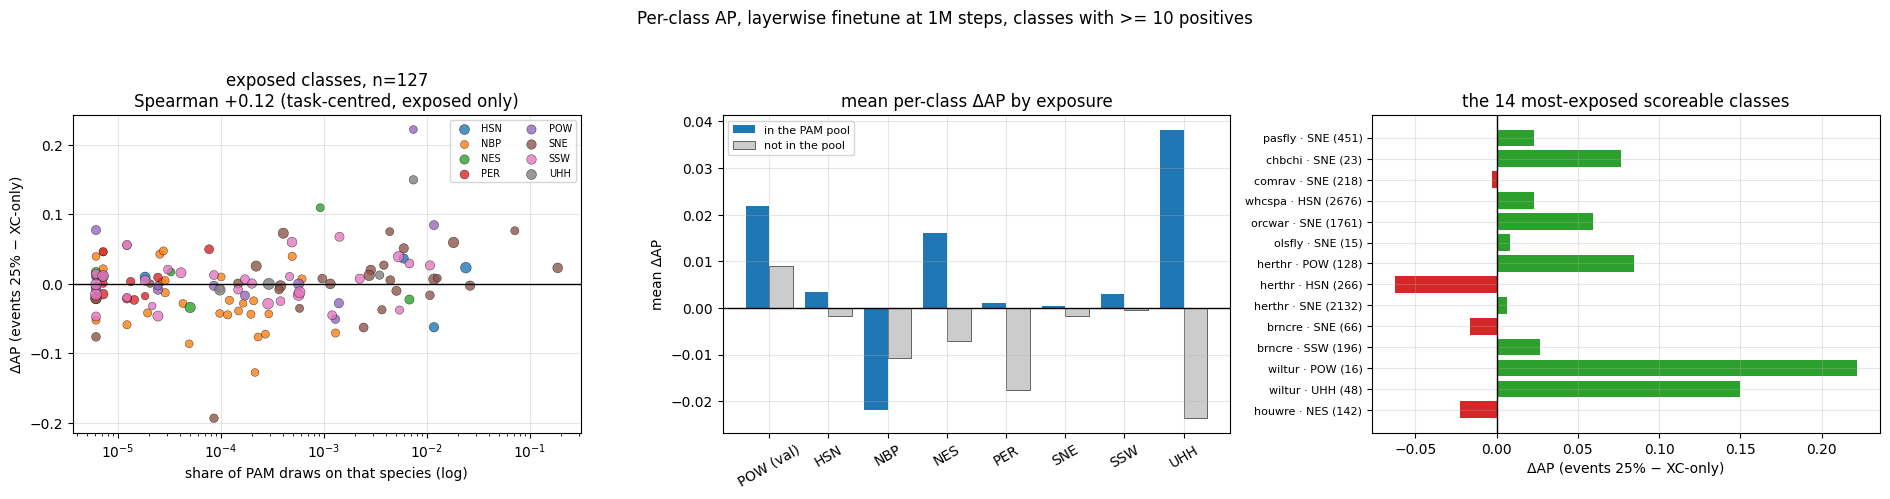

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
ft = per_class[(per_class["contrast"] == "finetune 1M") & (per_class["n_pos"] >= POS_MIN)]

# 1) exposure vs per-class delta, one point per class
ax = axes[0]
for task, s in ft.groupby("task"):
    m = s["exposed"]
    ax.scatter(s.loc[m, "pam_mass"], s.loc[m, "d_ap"], s=18 + 12 * np.log10(s.loc[m, "n_pos"]),
               alpha=0.8, label=task, edgecolor="black", linewidth=0.3)
ax.axhline(0, color="black", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("share of PAM draws on that species (log)")
ax.set_ylabel("ΔAP (events 25% − XC-only)")
_e = ft[ft["exposed"]].assign(d_c=lambda s: s["d_ap"] - s.groupby("task")["d_ap"].transform("mean"))
r = spearmanr(_e["pam_mass"], _e["d_c"])
ax.set_title(f"exposed classes, n={len(_e)}\nSpearman {r.statistic:+.2f} (task-centred, exposed only)")
ax.legend(fontsize=7, ncol=2)

# 2) per-task exposed vs unexposed mean
ax = axes[1]
tbl = exp_tbl.loc["finetune 1M"].reindex(TASKS).dropna(how="all")
x = np.arange(len(tbl))
ax.bar(x - 0.2, tbl["d_exposed"], 0.4, label="in the PAM pool", color="#1f77b4")
ax.bar(x + 0.2, tbl["d_unexposed"], 0.4, label="not in the pool", color="#cccccc", edgecolor="black", linewidth=0.4)
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([f"{t}{' (val)' if t in VAL_TASKS else ''}" for t in tbl.index], rotation=30)
ax.set_ylabel("mean ΔAP")
ax.set_title("mean per-class ΔAP by exposure")
ax.legend(fontsize=8)

# 3) the individual relevant classes, highest exposure first
ax = axes[2]
top = relevant[relevant["contrast"] == "finetune 1M"].head(14).iloc[::-1]
lab = [f"{r.ebird} · {r.task} ({r.n_pos})" for r in top.itertuples()]
ax.barh(np.arange(len(top)), top["d_ap"],
        color=["#2ca02c" if v > 0 else "#d62728" for v in top["d_ap"]])
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(np.arange(len(top)))
ax.set_yticklabels(lab, fontsize=8)
ax.set_xlabel("ΔAP (events 25% − XC-only)")
ax.set_title("the 14 most-exposed scoreable classes")

for ax in axes:
    ax.grid(alpha=0.3)
fig.suptitle(f"Per-class AP, layerwise finetune at 1M steps, classes with >= {POS_MIN} positives", y=1.03)
fig.tight_layout()
plt.show()

## Reading

### The pool is off-target, and part of it cannot register at all

1. **~34 % of PAM exposure is taxonomically disjoint from every task.** At the 0.7
   threshold the whole BioScape pool yields **1,192 on-target detections — 1.7 h of
   its 65 h** (2.6 %), against 75 % for S2L. A third of the PAM budget cannot carry
   target-taxon signal to any BirdSet task.
2. **The single largest species in the pool was unscoreable — and now is not.**
   `pasfly` (*Empidonax difficilis*) is **18.7 % of all PAM draws** and was in no
   task's probe label space: it was `SNE`'s dropped class (§6). The three task
   configs now restore the missing gbifIDs, so `SNE`'s on-target exposure reads
   **0.470 nominal → 0.410 scoreable** (the 0.059 residual is unresolved names, not
   verified absences), and §10 scores `pasfly` directly on its 451 positive
   windows: **+0.023 AP** finetuning, **+0.028 AP** probing.
3. **Per-task exposure is ~1 % for 4 of 7 tasks** and 6.5–8.8 % for `HSN`/`SSW`/`POW`.
   §3 and §7 are not in tension: 53 % of the events pool is in *some* task's label
   space (union = 411 species), while any single task sees ~1–9 % of it.

**The §6 loose end is closed.** The omissions were never "no XC data" —
*E. difficilis* has **251 XC recordings** and `UHH` *keeps* two classes with
**zero** — but a failed GBIF linkage in BirdSet's metadata. Repairing it costs
three config lines and turns the highest-leverage cell in the analysis from an
excuse into a measurement (§10).

### The pool is marginal-confidence, but not pseudo-replicated

**Purity is the weak point.** 95.6 % of S2L detections and 80.7 % of BioScape's sit
in `[0.7, 0.8)`, and **no S2L detection exceeds 0.9**. The pool is almost entirely
windows that barely cleared threshold, so "field-recorded bird vocalisations" is
doing work the detector may not support. `pasfly`'s confidence profile (§8, right
panel) is what to read before treating its 28 % share of S2L as real abundance.

**Diversity is fine, and this kills a plausible worry.** Median 1 detection per
granule, max 12, the top 1 % of granules hold ~5 % of detections, the largest site
3.5 %. The 216 h is not a few recordings replicated.

### The correlation survives its rivals, in one arm

`pam_mass_on_target` is **uncorrelated with XC training volume** (Spearman 0.000),
and partialling out XC volume, label-space size or baseline cmAP leaves the
`events 25%` relation unchanged or slightly stronger (0.714 → 0.715 / 0.762 / 0.765
/ 0.741). The cleanest single illustration: `NBP` has **108,217 XC recordings**, more
than four times any other task, and is the *worst* task in the two 25 % arms — so
"tasks with more training data benefit more" is not what is happening.

It is still only clean in that one arm (`regions 25%` 0.07, `regions 50%` 0.39),
`SNE` remains a leverage point in both variables, and §6 moved `SNE`'s x-value by
40 %. And `regions 25%` shows a different pattern entirely — its delta is strongly
*anti*-correlated with baseline cmAP (−0.857), i.e. it hurts most where the XC-only
backbone is strongest, which is not what H predicts and deserves its own look.

### What this establishes

Not a verdict on field audio — a **design flaw in the arms that produced the null**.
The pool was selected for detector confidence, not label-space overlap, so on-target
exposure is ~1 % for most tasks, and until the §6 repair ~19 % of the budget was
spent on a species no probe could score. A null on those tasks is the expected outcome, and any claim that
"unlabeled PAM does not help focal→soundscape transfer" has to be scoped to *this*
pool.

### The fix is already on disk

§7 is the actionable part. **480 h of on-target audio is already materialized** in
the regions store (51 % of its 941 h) needing no new download, and the full
0.4-threshold scan holds **1,626 h** of on-target S2L without re-scanning source
granules. A taxon-matched pool would be **96.8 % S2L** — one Californian avifauna —
which is the honest limit of this corpus and should be stated rather than discovered
later.

Two consequences for the next arm, whenever pretraining reopens:

* Restricting to BirdSet species costs little in hours (480 h vs the 932 h the
  regions arm used) but changes what the mix *is*: essentially all-S2L, Californian,
  best matched to `SNE`/`HSN`.
* Dropping BioScape is nearly free with respect to these benchmarks — 1.7 h
  on-target at 0.7 — so it has to be justified as domain diversity, not data volume.

### The sharpest remaining test, run: per-class AP

§10 is that test. `map_per_class` (`average: null`) turns 7 task-level deltas into
505 (task, class) points, and the layerwise **finetune** pair at 1M steps
(`XC_1M` vs `XC_nasa_1M` — the events 25 % mix, same schedule on both sides) covers
all 8 tasks. Restricted to the 352 test-task classes with ≥ 10 positive windows:

* **The direction is right; the effect is not resolved.** Classes in the pool
  average **−0.002 ΔAP** against **−0.012** for classes outside it, and the gap is
  positive in **6 of 7** test tasks (mean +0.015). But it is confounded by task
  identity — the tasks with the most exposed classes are the tasks with the least
  negative deltas — and after removing each task's own mean the gap falls to
  +0.005 vs −0.002 (Mann-Whitney p = 0.22), with Spearman(exposure, ΔAP) = +0.07.
* **Exposure-weighted the mix looks positive: +0.026 ΔAP against −0.009
  unweighted.** Real but thin — `pam_mass` is concentrated enough that the weighted
  mean has an **effective sample size of 5.4 classes**, essentially `pasfly`
  (+0.023, 451 positives) and `chbchi` (+0.076, 23 positives).
* **The individual predictions half-hold.** Of the 127 relevant classes (exposed,
  ≥ 10 positives) **61 improve** — a coin flip on count — but the most-exposed ones
  lean positive: `pasfly` +0.023, `chbchi` +0.076, `orcwar` +0.059, `whcspa` +0.023,
  `daejun` +0.051 / +0.036, against `comrav` −0.003 and `herthr` +0.084 (`POW`) /
  −0.063 (`HSN`) — the same species moving both ways across tasks, which is what an
  unmeasured noise floor looks like.
* **It does not replicate on the other arm.** The frozen probe at 400k
  (`regions 25 %`, `SNE`/`NES`/`PER` only) puts the gap at **0/3** tasks and
  Spearman at −0.03 — §5's arm inconsistency again, now at class level.

So the per-class view neither rescues the NASA arms nor refutes H. What it does
settle is that **the null is not an artefact of the unscoreable class**: `pasfly` is
scoreable now, it is the most-exposed class in the benchmark, and it moves +0.023 AP
— which would have to be ~10× larger across ~50 such classes to surface as a
task-level cmAP gain. The lever is the *number* of well-exposed classes per task,
and §7 says that is a curation choice, not a pretraining one.

Two things to re-check before quoting these numbers: `SSW`'s NASA side was still
running when the section was executed (its two columns will move), and there is
still **no per-class noise floor** — one probe seed per cell, against a task-level
init effect of ±0.014 cmAP.
